In [3]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_c32d5c3ab2ea2aff5e97a66ac357404d"

In [4]:
import kagglehub

path_dataset = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


In [5]:
import os
import random
import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# CONFIGURACIÓN DE SEMILLAS
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)  # Fijamos la semilla en 42

# 1. Rutas y lectura de datos
csv_path = os.path.join(path_dataset, 'HAM10000_metadata.csv')
df = pd.read_csv(csv_path)

# Mapeamos las imágenes buscando en ambas carpetas
dir1 = os.path.join(path_dataset, 'HAM10000_images_part_1')
dir2 = os.path.join(path_dataset, 'HAM10000_images_part_2')
img_map = {os.path.splitext(f)[0]: os.path.join(d, f) for d in [dir1, dir2] if os.path.exists(d) for f in os.listdir(d)}

df['image_path'] = df['image_id'].map(img_map)
df['label'] = pd.Categorical(df['dx']).codes

# 2. Partición 80% entrenamiento y 20% validación
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# 3. Transformaciones básicas
train_tx = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tx = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Dataset mínimo y Cargadores
class SkinDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img = Image.open(self.data.iloc[idx]['image_path']).convert('RGB')
        return self.transform(img), int(self.data.iloc[idx]['label'])

train_loader = DataLoader(SkinDataset(train_df, train_tx), batch_size=32, shuffle=True)
val_loader = DataLoader(SkinDataset(val_df, val_tx), batch_size=32, shuffle=False)

print(f"Entrenamiento: {len(train_df)} imágenes | Validación: {len(val_df)} imágenes")

Entrenamiento: 8012 imágenes | Validación: 2003 imágenes


In [6]:
import torch
import torch.nn as nn
import torchvision.models as models

# 1. Configurar la GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Cargar EfficientNet-B0 con pesos por defecto
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 3. Cambiar la capa final y definir optimizador
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 7)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 192MB/s]


In [7]:
epochs = 4

for epoch in range(epochs):
    # ENTRENAMIENTO
    model.train()
    train_loss, train_correct = 0.0, 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, lbls)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        train_correct += (outs.argmax(1) == lbls).sum().item()

    # VALIDACIÓN
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outs = model(imgs)
            loss = criterion(outs, lbls)

            val_loss += loss.item() * imgs.size(0)
            val_correct += (outs.argmax(1) == lbls).sum().item()

    # Resultados de cada época
    print(f"\nÉpoca {epoch+1}/{epochs}:")
    print(f"  Entrenamiento -> Loss: {train_loss/len(train_df):.4f} | Accuracy: {train_correct/len(train_df)*100:.2f}%")
    print(f"  Validación    -> Loss: {val_loss/len(val_df):.4f} | Accuracy: {val_correct/len(val_df)*100:.2f}%")

print("\nEntrenamiento finalizado.")


Época 1/4:
  Entrenamiento -> Loss: 0.7000 | Accuracy: 75.07%
  Validación    -> Loss: 0.5643 | Accuracy: 79.48%

Época 2/4:
  Entrenamiento -> Loss: 0.5113 | Accuracy: 81.13%
  Validación    -> Loss: 0.4996 | Accuracy: 82.13%

Época 3/4:
  Entrenamiento -> Loss: 0.4200 | Accuracy: 84.89%
  Validación    -> Loss: 0.6244 | Accuracy: 78.83%

Época 4/4:
  Entrenamiento -> Loss: 0.3439 | Accuracy: 87.71%
  Validación    -> Loss: 0.4605 | Accuracy: 82.88%

Entrenamiento finalizado.


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

# 1. Pasamos el modelo a modo evaluación
model.eval()
y_true, y_pred = [], []

# 2. Obtenemos las predicciones finales
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        outs = model(imgs)
        _, preds = torch.max(outs, 1)
        y_true.extend(lbls.numpy())
        y_pred.extend(preds.cpu().numpy())

nombres_clases = pd.Categorical(df['dx']).categories.tolist()

# 3. Mostramos las métricas en pantalla
print(f"Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
print(f"Macro Recall: {recall_score(y_true, y_pred, average='macro')*100:.2f}%\n")
print("Matriz de Confusion:")
print(confusion_matrix(y_true, y_pred))
print("\n" + classification_report(y_true, y_pred, target_names=nombres_clases))

Accuracy: 82.88%
Macro Recall: 66.76%

Matriz de Confusion:
[[  47    1    1    2   13    1    0]
 [  17   61    4    4    4   13    0]
 [   9    6  113    1   56   35    0]
 [   2    0    0   16    2    3    0]
 [   5    2    3    0  160   53    0]
 [   1    5   12    1   72 1249    1]
 [   2    1    1    0    7    3   14]]

              precision    recall  f1-score   support

       akiec       0.57      0.72      0.64        65
         bcc       0.80      0.59      0.68       103
         bkl       0.84      0.51      0.64       220
          df       0.67      0.70      0.68        23
         mel       0.51      0.72      0.60       223
          nv       0.92      0.93      0.93      1341
        vasc       0.93      0.50      0.65        28

    accuracy                           0.83      2003
   macro avg       0.75      0.67      0.69      2003
weighted avg       0.85      0.83      0.83      2003



In [9]:
from google.colab import files

In [10]:

# 1. Guardamos y descargamos el archivo
torch.save(model.state_dict(), 'pesos_efficientnet.pth')

files.download('pesos_efficientnet.pth')
print("Archivo .pth descargado. Muévelo a la carpeta de Vscode.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivo .pth descargado. Muévelo a la carpeta de Vscode.


In [11]:

# 1. Configurar la GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Cargar ResNet50 con pesos por defecto
model_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 3. Cambiar la capa final (en ResNet es 'fc') y definir optimizador propio
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(in_features, 7)
model_resnet = model_resnet.to(device)

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(model_resnet.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 226MB/s]


In [12]:
epochs = 4

for epoch in range(epochs):
    # ENTRENAMIENTO
    model_resnet.train()
    train_loss, train_correct = 0.0, 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer_resnet.zero_grad()
        outs = model_resnet(imgs)
        loss = criterion_resnet(outs, lbls)
        loss.backward()
        optimizer_resnet.step()

        train_loss += loss.item() * imgs.size(0)
        train_correct += (outs.argmax(1) == lbls).sum().item()

    # VALIDACIÓN
    model_resnet.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outs = model_resnet(imgs)
            loss = criterion_resnet(outs, lbls)

            val_loss += loss.item() * imgs.size(0)
            val_correct += (outs.argmax(1) == lbls).sum().item()

    # Resultados de cada época
    print(f"\nÉpoca {epoch+1}/{epochs} (ResNet50):")
    print(f"  Entrenamiento -> Loss: {train_loss/len(train_df):.4f} | Accuracy: {train_correct/len(train_df)*100:.2f}%")
    print(f"  Validación    -> Loss: {val_loss/len(val_df):.4f} | Accuracy: {val_correct/len(val_df)*100:.2f}%")

print("\nEntrenamiento de ResNet50 finalizado.")


Época 1/4 (ResNet50):
  Entrenamiento -> Loss: 0.7832 | Accuracy: 72.19%
  Validación    -> Loss: 0.7414 | Accuracy: 75.64%

Época 2/4 (ResNet50):
  Entrenamiento -> Loss: 0.6372 | Accuracy: 76.66%
  Validación    -> Loss: 1.1172 | Accuracy: 67.50%

Época 3/4 (ResNet50):
  Entrenamiento -> Loss: 0.5663 | Accuracy: 78.84%
  Validación    -> Loss: 0.7305 | Accuracy: 75.44%

Época 4/4 (ResNet50):
  Entrenamiento -> Loss: 0.4946 | Accuracy: 81.75%
  Validación    -> Loss: 0.5950 | Accuracy: 79.88%

Entrenamiento de ResNet50 finalizado.


In [13]:

# 1. Pasamos ResNet50 a modo evaluación
model_resnet.eval()
y_true_resnet, y_pred_resnet = [], []

# 2. Obtenemos las predicciones
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        outs = model_resnet(imgs)
        _, preds = torch.max(outs, 1)
        y_true_resnet.extend(lbls.numpy())
        y_pred_resnet.extend(preds.cpu().numpy())

nombres_clases = pd.Categorical(df['dx']).categories.tolist()

# 3. Mostramos las métricas de ResNet50
print(f"Accuracy ResNet50: {accuracy_score(y_true_resnet, y_pred_resnet)*100:.2f}%")
print(f"Macro Recall ResNet50: {recall_score(y_true_resnet, y_pred_resnet, average='macro')*100:.2f}%\n")
print("Matriz de Confusion ResNet50:")
print(confusion_matrix(y_true_resnet, y_pred_resnet))
print("\n" + classification_report(y_true_resnet, y_pred_resnet, target_names=nombres_clases))

Accuracy ResNet50: 79.88%
Macro Recall ResNet50: 50.48%

Matriz de Confusion ResNet50:
[[  18   17   10    0    8   12    0]
 [   0   77   10    0    4   12    0]
 [   4   11  117    0   24   64    0]
 [   1    2    3    4    4    9    0]
 [   2    6   24    1   94   96    0]
 [   0    8   27    0   24 1278    4]
 [   1    8    0    0    3    4   12]]

              precision    recall  f1-score   support

       akiec       0.69      0.28      0.40        65
         bcc       0.60      0.75      0.66       103
         bkl       0.61      0.53      0.57       220
          df       0.80      0.17      0.29        23
         mel       0.58      0.42      0.49       223
          nv       0.87      0.95      0.91      1341
        vasc       0.75      0.43      0.55        28

    accuracy                           0.80      2003
   macro avg       0.70      0.50      0.55      2003
weighted avg       0.79      0.80      0.78      2003



In [22]:

# Guardamos los pesos
torch.save(model_resnet.state_dict(), 'pesos_resnet50.pth')

files.download('pesos_resnet50.pth')
print("Archivo pesos_resnet50.pth descargado.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivo pesos_resnet50.pth descargado.


**APLICACIÓN Grad-CAM**

In [15]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 110.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=13b9f939806962b96b3fbbd1f6f7bba1cac49b988cc919095f5eaa7223ce0640
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [17]:
# CONFIGURACIÓN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

efficientnet_model = model   # Referente a efficient
resnet_model = model_resnet  # Referente a resnet50

test_dataset = SkinDataset(val_df, val_tx)

# Nombres de las 7 clases
class_names = nombres_clases

In [18]:
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F


#  GRAD-CAM

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        # Se registran los hooks para capturar activaciones y gradientes
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def compute_heatmap(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx == None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        # Extracción de gradientes y activaciones
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]

        # Pesos (Average pooling de los gradientes)
        weights = np.mean(gradients, axis=(1, 2))

        # Combinación lineal de las activaciones
        heatmap = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            heatmap += w * activations[i]

        # Pasar por ReLU (tomamos solo positivas)
        heatmap = np.maximum(heatmap, 0)

        # Normalizar entre 0 y 1
        if np.max(heatmap) != 0:
            heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

        return heatmap, class_idx



# VISUALIZACIÓN

def show_gradcam(img_tensor, heatmap, title="Grad-CAM"):
    # Desnormalización de la imagen (se muestra en RGB)
    img = img_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img * std + mean).clip(0, 1)

    # Redimensionar el mapa de calor al tamaño original de la imagen (224x224)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

    # Superponer mapa de calor e imagen original (0.6 original + 0.4 mapa de calor)
    overlay = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)

    # Representación de resultados resultados
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagen Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(title)
    plt.axis("off")
    plt.show()

**EFFICIENTNET**

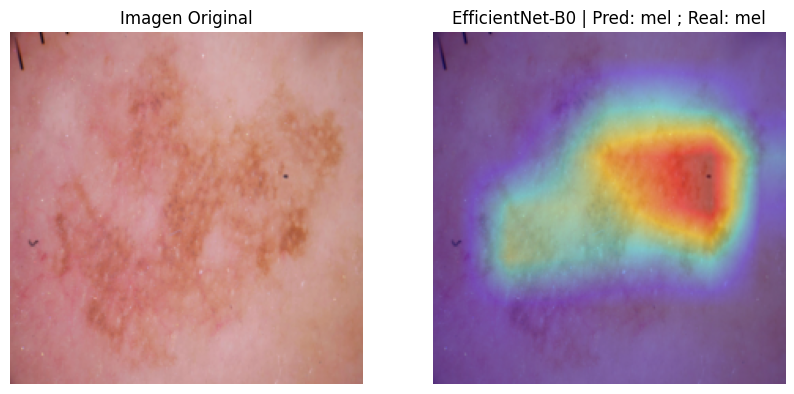

In [43]:

# Se toma una imagen del dataset de validación cualquiera
img_original, true_label = test_dataset[13]
input_tensor = img_original.unsqueeze(0).to(device) # Añadir dimensión de batch

# Se configura Grad-CAM para EfficientNet
target_layer_eff = efficientnet_model.features[-1]
cam_eff = GradCAM(efficientnet_model, target_layer_eff)

# Generar y representar
heatmap, pred_idx = cam_eff.compute_heatmap(input_tensor)
show_gradcam(
    img_tensor=input_tensor,
    heatmap=heatmap,
    title=f"EfficientNet-B0 | Pred: {class_names[pred_idx]} ; Real: {class_names[true_label]}"
)

**RESNET50**

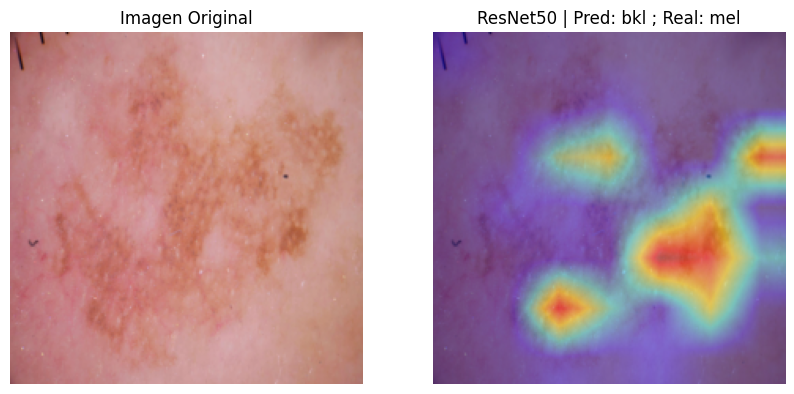

In [42]:
# Cambiar valor para tomar otra imagen
img_original, true_label = test_dataset[13]
input_tensor = img_original.unsqueeze(0).to(device) # Añadir dimensión de batch

# Configuración para RESNET50
target_layer_res = resnet_model.layer4[-1]
cam_res = GradCAM(resnet_model, target_layer_res)

# Generación y representación
heatmap_res, pred_idx_res = cam_res.compute_heatmap(input_tensor)
show_gradcam(
    img_tensor=input_tensor,
    heatmap=heatmap_res,
    title=f"ResNet50 | Pred: {class_names[pred_idx_res]} ; Real: {class_names[true_label]}"
)

Curioso comparar el mapa de calor de las imágenes: 1, 5 (mal por parte del resnet50), 7 (Idem), 13 (Importante para la memoria del TFM, no detecta el melanoma),...